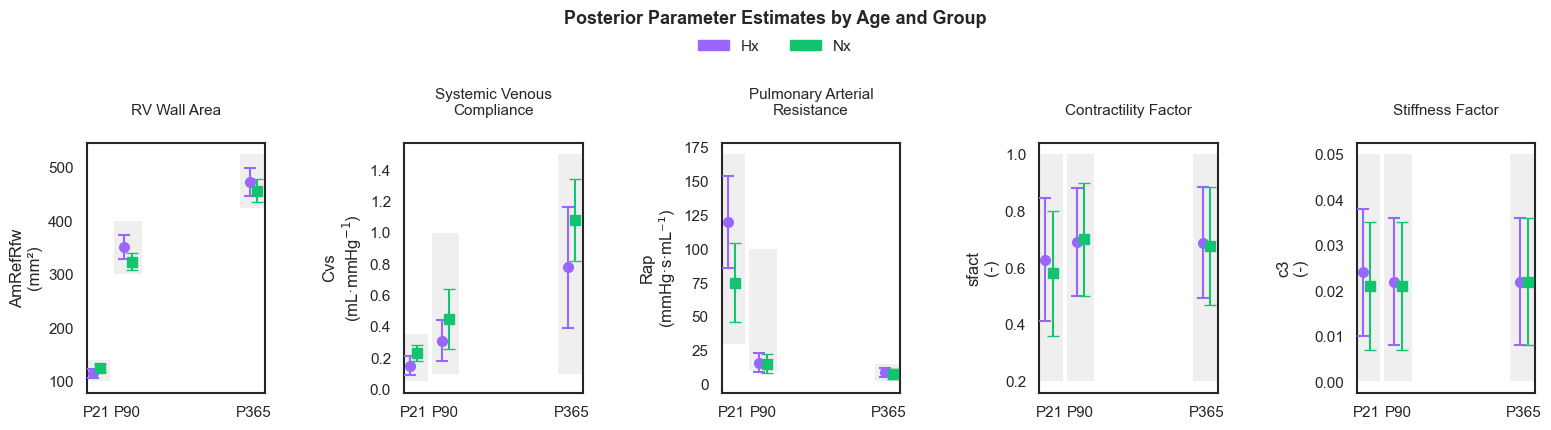

In [31]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

sns.set_theme(style="white", palette=None)

color_hx = (0.6, 0.4, 1.0)   # purple
color_nx = (0.07, 0.77, 0.44) # green
ages = [21, 90, 365]

titles = [
    'RV Wall Area',
    'Systemic Venous\nCompliance',
    'Pulmonary Arterial\nResistance',
    'Contractility Factor',
    'Stiffness Factor',
]


params = {
    'AmRefRfw\n(mm²)': {
        21:  {'Hx': (115, 8),   'Nx': (125, 7)},
        90:  {'Hx': (351, 22),  'Nx': (324, 16)},
        365: {'Hx': (473, 27),  'Nx': (457, 22)},
        'ranges': {21: (100,140), 90: (300,400), 365: (425,525)}
    },
    'Cvs\n(mL·mmHg$^{-1}$)': {
        21:  {'Hx': (0.15, 0.06),  'Nx': (0.23, 0.05)},
        90:  {'Hx': (0.31, 0.13),  'Nx': (0.45, 0.19)},
        365: {'Hx': (0.777, 0.384),'Nx': (1.08, 0.26)},
        'ranges': {21: (0.05,0.35), 90: (0.1,1), 365: (0.1,1.5)}
    },
    'Rap\n(mmHg·s·mL${⁻¹}$)': {
        21:  {'Hx': (120, 34), 'Nx': (75, 29)},
        90:  {'Hx': (16, 7),   'Nx': (15, 7)},
        365: {'Hx': (8.63, 3.65), 'Nx': (7.66, 3.57)},
        'ranges': {21: (30,170), 90: (10,100), 365: (2,15)}
    },
    'sfact\n(-)': {
        21:  {'Hx': (0.629, 0.218), 'Nx': (0.58, 0.22)},
        90:  {'Hx': (0.69, 0.19),   'Nx': (0.70, 0.20)},
        365: {'Hx': (0.689, 0.196), 'Nx': (0.676, 0.207)},
        'ranges': {21: (0.2,1), 90: (0.2,1), 365: (0.2,1)}
    },
    'c3\n(-)': {
        21:  {'Hx': (0.024, 0.014), 'Nx': (0.021, 0.014)},
        90:  {'Hx': (0.022, 0.014), 'Nx': (0.021, 0.014)},
        365: {'Hx': (0.022, 0.014), 'Nx': (0.022, 0.014)},
        'ranges': {21: (5e-5, 5e-2), 90: (5e-5, 5e-2), 365: (5e-5, 5e-2)}
    },
}

offset = 8
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, (param_name, data) in zip(axes, params.items()):
    for age in ages:
        rng = data['ranges'][age]
        ax.fill_between(
            [age - 30, age + 30], rng[0], rng[1],
            alpha=0.12, color='gray', linewidth=0
        )

    hx_vals = [data[age]['Hx'] for age in ages]
    nx_vals = [data[age]['Nx'] for age in ages]

    hx_means = [v[0] for v in hx_vals]
    hx_stds  = [v[1] for v in hx_vals]
    nx_means = [v[0] for v in nx_vals]
    nx_stds  = [v[1] for v in nx_vals]

    ages_hx = [a - offset for a in ages]
    ages_nx = [a + offset for a in ages]

    # 'o' and 's' with no line (removed '-' and '--')
    ax.errorbar(ages_hx, hx_means, yerr=hx_stds,
                fmt='o', color=color_hx, linewidth=0, markersize=7,
                capsize=4, capthick=1.5, elinewidth=1.5, label='Hx', zorder=5)
    ax.errorbar(ages_nx, nx_means, yerr=nx_stds,
                fmt='s', color=color_nx, linewidth=0, markersize=7,
                capsize=4, capthick=1.5, elinewidth=1.5, label='Nx',
                markeredgecolor=color_nx, markeredgewidth=1.0, zorder=5)

    ax.set_xticks(ages)
    ax.set_xticklabels(['P21', 'P90', 'P365'])
    ax.set_ylabel(param_name)
    ax.set_xlim(0, 390)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(width=1.5)
    ax.set_box_aspect(1.4)

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=11, pad=6, y=1.08)

hx_patch = mpatches.Patch(color=color_hx, label='Hx')
nx_patch = mpatches.Patch(color=color_nx, label='Nx')
fig.legend(handles=[hx_patch, nx_patch], loc='upper center',
           ncol=2, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Posterior Parameter Estimates by Age and Group", fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

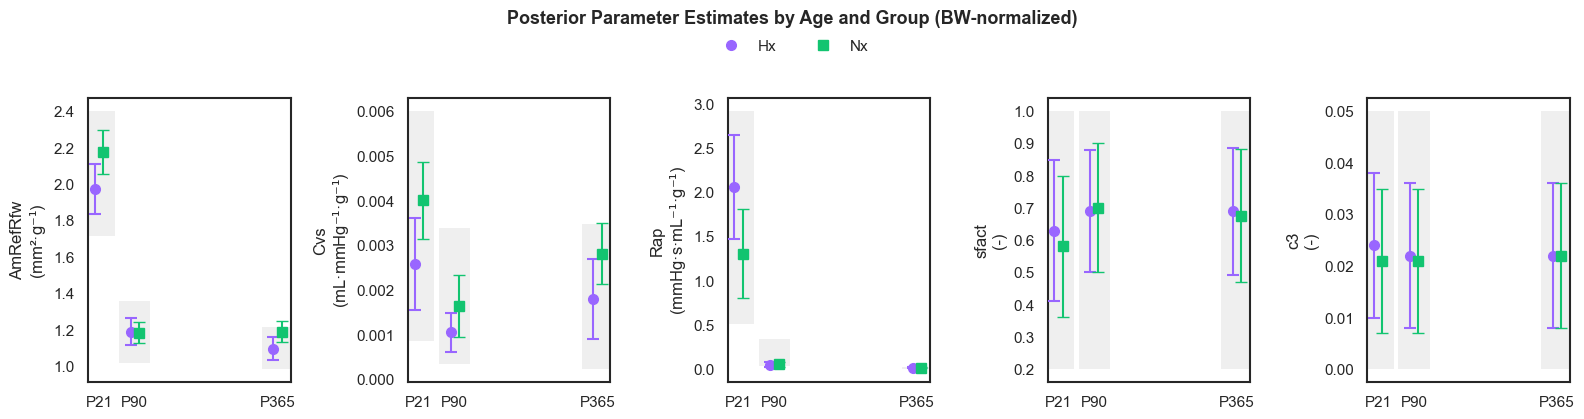

In [6]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="white", palette=None)

color_hx = (0.6, 0.4, 1.0)   # purple
color_nx = (0.07, 0.77, 0.44) # green
ages = [21, 90, 365]
offset = 8

# Body weights in grams
bw = {
    'Hx': {21: 58.34, 90: 295.0, 365: 431.5},
    'Nx': {21: 57.46, 90: 273.5, 365: 384.0},
}

# Raw data: (mean, std)
raw = {
    'AmRefRfw': {
        21:  {'Hx': (115, 8),        'Nx': (125, 7)},
        90:  {'Hx': (351, 22),       'Nx': (324, 16)},
        365: {'Hx': (473, 27),       'Nx': (457, 22)},
        'ranges': {21: (100,140), 90: (300,400), 365: (425,525)},
        'ylabel': 'AmRefRfw\n(mm²·g${⁻¹}$)',
    },
    'Cvs': {
        21:  {'Hx': (0.15, 0.06),    'Nx': (0.23, 0.05)},
        90:  {'Hx': (0.31, 0.13),    'Nx': (0.45, 0.19)},
        365: {'Hx': (0.777, 0.384),  'Nx': (1.08, 0.26)},
        'ranges': {21: (0.05,0.35), 90: (0.1,1), 365: (0.1,1.5)},
        'ylabel': 'Cvs\n(mL·mmHg${⁻¹}$·g${⁻¹}$)',
    },
    'Rap': {
        21:  {'Hx': (120, 34),       'Nx': (75, 29)},
        90:  {'Hx': (16, 7),         'Nx': (15, 7)},
        365: {'Hx': (8.63, 3.65),    'Nx': (7.66, 3.57)},
        'ranges': {21: (30,170), 90: (10,100), 365: (2,12)},
        'ylabel': 'Rap\n(mmHg·s·mL${⁻¹}$·g${⁻¹}$)',
    },
    'sfact': {
        21:  {'Hx': (0.629, 0.218),  'Nx': (0.58, 0.22)},
        90:  {'Hx': (0.69, 0.19),    'Nx': (0.70, 0.20)},
        365: {'Hx': (0.689, 0.196),  'Nx': (0.676, 0.207)},
        'ranges': {21: (0.2,1), 90: (0.2,1), 365: (0.2,1)},
        'ylabel': 'sfact\n(-)',
    },
    'c3': {
        21:  {'Hx': (0.024, 0.014),  'Nx': (0.021, 0.014)},
        90:  {'Hx': (0.022, 0.014),  'Nx': (0.021, 0.014)},
        365: {'Hx': (0.022, 0.014),  'Nx': (0.022, 0.014)},
        'ranges': {21: (5e-5,5e-2), 90: (5e-5,5e-2), 365: (5e-5,5e-2)},
        'ylabel': 'c3\n(-)',
    },
}

# Parameters to normalize (sfact and c3 are dimensionless, skip)
normalize = {'AmRefRfw', 'Cvs', 'Rap'}

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for ax, (param, data) in zip(axes, raw.items()):
    do_norm = param in normalize

    for age in ages:
        rng = data['ranges'][age]
        if do_norm:
            rng = (rng[0] / bw['Hx'][age], rng[1] / bw['Hx'][age])  # shade using Hx BW
        ax.fill_between(
            [age - 30, age + 30], rng[0], rng[1],
            alpha=0.12, color='gray', linewidth=0
        )

    ages_hx = [a - offset for a in ages]
    ages_nx = [a + offset for a in ages]

    hx_means, hx_stds, nx_means, nx_stds = [], [], [], []
    for age in ages:
        hm, hs = data[age]['Hx']
        nm, ns = data[age]['Nx']
        if do_norm:
            hm, hs = hm / bw['Hx'][age], hs / bw['Hx'][age]
            nm, ns = nm / bw['Nx'][age], ns / bw['Nx'][age]
        hx_means.append(hm); hx_stds.append(hs)
        nx_means.append(nm); nx_stds.append(ns)

    ax.errorbar(ages_hx, hx_means, yerr=hx_stds,
                fmt='o', color=color_hx, linewidth=0, markersize=7,
                capsize=4, capthick=1.5, elinewidth=1.5, label='Hx', zorder=5)
    ax.errorbar(ages_nx, nx_means, yerr=nx_stds,
                fmt='s', color=color_nx, linewidth=0, markersize=7,
                capsize=4, capthick=1.5, elinewidth=1.5, label='Nx',
                markeredgecolor=color_nx, markeredgewidth=1.0, zorder=5)

    ax.set_xticks(ages)
    ax.set_xticklabels(['P21', 'P90', 'P365'])
    ax.set_ylabel(data['ylabel'])
    ax.set_xlim(0, 390)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(width=1.5)
    ax.set_box_aspect(1.4)

# Legend with correct symbols
hx_handle = axes[-1].errorbar([], [], fmt='o', color=color_hx, markersize=7,
                               capsize=4, capthick=1.5, elinewidth=1.5, label='Hx')
nx_handle = axes[-1].errorbar([], [], fmt='s', color=color_nx, markersize=7,
                               capsize=4, capthick=1.5, elinewidth=1.5, label='Nx',
                               markeredgecolor=color_nx, markeredgewidth=1.0)
fig.legend(handles=[hx_handle, nx_handle], loc='upper center',
           ncol=2, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Posterior Parameter Estimates by Age and Group (BW-normalized)", 
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()

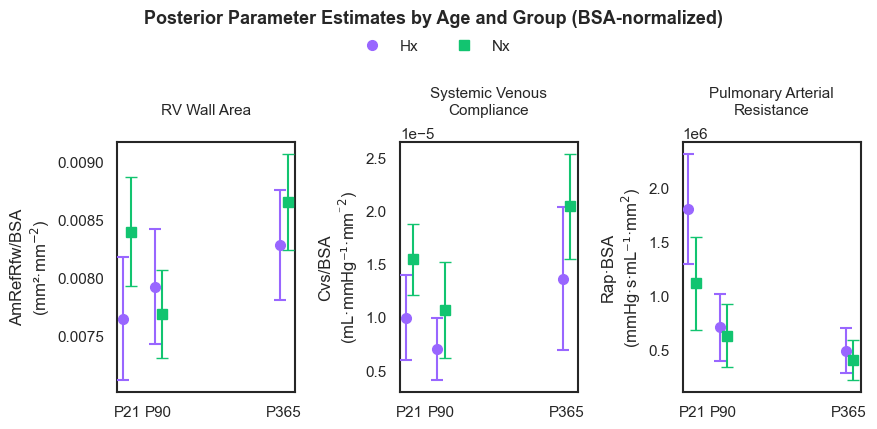

In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="white", palette=None)

color_hx = (0.6, 0.4, 1.0)   # purple
color_nx = (0.07, 0.77, 0.44) # green
ages = [21, 90, 365]
offset = 8

titles = [
    'RV Wall Area',
    'Systemic Venous\nCompliance',
    'Pulmonary Arterial\nResistance',
    'sfact',
    'c3',
]

# Body weights in grams
bw = {
    'Hx': {21: 58.34, 90: 295.0, 365: 431.5},
    'Nx': {21: 57.46, 90: 273.5, 365: 384.0},
}

# BSA = 10 * BW^(2/3), computed from BW
bsa = {
    group: {age: 10 * bw[group][age]**(2/3)*100 for age in ages}
    for group in ['Hx', 'Nx']
}

# Raw data: (mean, std)
raw = {
    'AmRefRfw': {
        21:  {'Hx': (115, 8),        'Nx': (125, 7)},
        90:  {'Hx': (351, 22),       'Nx': (324, 16)},
        365: {'Hx': (473, 27),       'Nx': (457, 22)},
        'ranges': {21: (100,140), 90: (300,400), 365: (425,525)},
        'ylabel': 'AmRefRfw/BSA\n(mm²·mm${^{-2}}$)',  # updated units: normalized by BSA (cm²)
    },
    'Cvs': {
        21:  {'Hx': (0.15, 0.06),    'Nx': (0.23, 0.05)},
        90:  {'Hx': (0.31, 0.13),    'Nx': (0.45, 0.19)},
        365: {'Hx': (0.777, 0.384),  'Nx': (1.08, 0.26)},
        'ranges': {21: (0.05,0.35), 90: (0.1,1), 365: (0.1,1.5)},
        'ylabel': 'Cvs/BSA\n(mL·mmHg${⁻¹}$·mm${^{⁻2}}$)',
    },
    'Rap': {
        21:  {'Hx': (120, 34),       'Nx': (75, 29)},
        90:  {'Hx': (16, 7),         'Nx': (15, 7)},
        365: {'Hx': (8.63, 3.65),    'Nx': (7.66, 3.57)},
        'ranges': {21: (30,170), 90: (10,100), 365: (2,12)},
        'ylabel': 'Rap·BSA\n(mmHg·s·mL${⁻¹}$·mm${^{2}}$)',
    },

}

# AmRefRfw normalized by BSA; Cvs and Rap normalized by BW; sfact and c3 dimensionless
normalize_bsa = {'AmRefRfw', 'Cvs', 'Rap'}
normalize_bw  = {}

fig, axes = plt.subplots(1, 3, figsize=(9, 4))

for ax, (param, data) in zip(axes, raw.items()):
    use_bsa = param in normalize_bsa

    # ranges
    for age in ages:
        rng = data['ranges'][age]
        if use_bsa and param == 'Rap':
            rng = (rng[0] * bsa['Hx'][age], rng[1] * bsa['Hx'][age])
        elif use_bsa:
            rng = (rng[0] / bsa['Hx'][age], rng[1] / bsa['Hx'][age])

    ages_hx = [a - offset for a in ages]
    ages_nx = [a + offset for a in ages]

    # data — single loop, correct logic
    hx_means, hx_stds, nx_means, nx_stds = [], [], [], []
    for age in ages:
        hm, hs = data[age]['Hx']
        nm, ns = data[age]['Nx']
        if use_bsa and param == 'Rap':
            hm, hs = hm * bsa['Hx'][age], hs * bsa['Hx'][age]
            nm, ns = nm * bsa['Nx'][age], ns * bsa['Nx'][age]
        elif use_bsa:  # AmRefRfw and Cvs
            hm, hs = hm / bsa['Hx'][age], hs / bsa['Hx'][age]
            nm, ns = nm / bsa['Nx'][age], ns / bsa['Nx'][age]
        hx_means.append(hm); hx_stds.append(hs)
        nx_means.append(nm); nx_stds.append(ns)

    ax.errorbar(ages_hx, hx_means, yerr=hx_stds,
                fmt='o', color=color_hx, linewidth=0, markersize=7,
                capsize=4, capthick=1.5, elinewidth=1.5, label='Hx', zorder=5)
    ax.errorbar(ages_nx, nx_means, yerr=nx_stds,
                fmt='s', color=color_nx, linewidth=0, markersize=7,
                capsize=4, capthick=1.5, elinewidth=1.5, label='Nx',
                markeredgecolor=color_nx, markeredgewidth=1.0, zorder=5)

    ax.set_xticks(ages)
    ax.set_xticklabels(['P21', 'P90', 'P365'])
    ax.set_ylabel(data['ylabel'])
    ax.set_xlim(0, 390)

    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
    ax.tick_params(width=1.5)
    ax.set_box_aspect(1.4)

for ax, title in zip(axes, titles):
    ax.set_title(title, fontsize=11, pad=6, y=1.08)

# Legend
hx_handle = axes[-1].errorbar([], [], fmt='o', color=color_hx, markersize=7,
                               capsize=4, capthick=1.5, elinewidth=1.5, label='Hx')
nx_handle = axes[-1].errorbar([], [], fmt='s', color=color_nx, markersize=7,
                               capsize=4, capthick=1.5, elinewidth=1.5, label='Nx',
                               markeredgecolor=color_nx, markeredgewidth=1.0)
fig.legend(handles=[hx_handle, nx_handle], loc='upper center',
           ncol=2, frameon=False, fontsize=11, bbox_to_anchor=(0.5, 1.02))

plt.suptitle("Posterior Parameter Estimates by Age and Group (BSA-normalized)", 
             fontsize=13, fontweight='bold', y=1.06)
plt.tight_layout()
plt.show()